Loading Libraries ---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading Dataset ---

In [2]:
df = pd.read_csv("C:/Data Analytics/Projects/Project3 E-commerce Customer Behavior & Revenue Analytics/online_retail_clean.csv")

Creating Customer Level Table ---

In [3]:
clv_df = df.groupby("CustomerID").agg({
    "InvoiceNo":"nunique",
    "Revenue":"sum"
})

Checking the Table ---

In [4]:
clv_df.head()

,InvoiceNo,Revenue
CustomerID,,
12346,1,77183.60
12347,7,4310.00
12348,4,1797.24
12349,1,1757.55
12350,1,334.40


Average Order Value (AOV) ---

In [5]:
clv_df["AOV"] = (
    clv_df["Revenue"]
    /
    clv_df["InvoiceNo"]
)

Purchase Frequency ---

In [6]:
purchase_frequency = (
    df["InvoiceNo"].nunique()
    /
    df["CustomerID"].nunique()
)

purchase_frequency

4.272014753342554

Customer Value ---

In [7]:
clv_df["Customer_Value"] = (
    clv_df["AOV"]
    *
    purchase_frequency
)

CLV ---

In [8]:
clv_df["CLV"] = (
    clv_df["Customer_Value"]
)

CLV Distribution ---

In [9]:
clv_df["CLV"].describe()

count      4338.000000
mean       1790.684573
std        7674.836604
min          14.738451
25%         763.088635
50%        1255.545136
75%        1837.452286
max      359858.502766
Name: CLV, dtype: float64

Segmenting Customers by CLV ---

In [10]:
clv_df["CLV_Segment"] = pd.qcut(
    clv_df["CLV"],
    q=3,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value"
    ]
)

Distribution ---

In [11]:
clv_df["CLV_Segment"].value_counts()

CLV_Segment
Low Value       1446
Medium Value    1446
High Value      1446
Name: count, dtype: int64

Revenue by CLV Segment ---

In [12]:
clv_revenue = (
    clv_df.groupby("CLV_Segment")["Revenue"]
          .sum()
          .sort_values(ascending=False)
)

clv_revenue

C:\Users\Hp\AppData\Local\Temp\ipykernel_12696\1236250455.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clv_df.groupby("CLV_Segment")["Revenue"]


CLV_Segment
High Value      6421728.692
Medium Value    1759987.900
Low Value        729691.312
Name: Revenue, dtype: float64

Customer Distribution Visualization ---

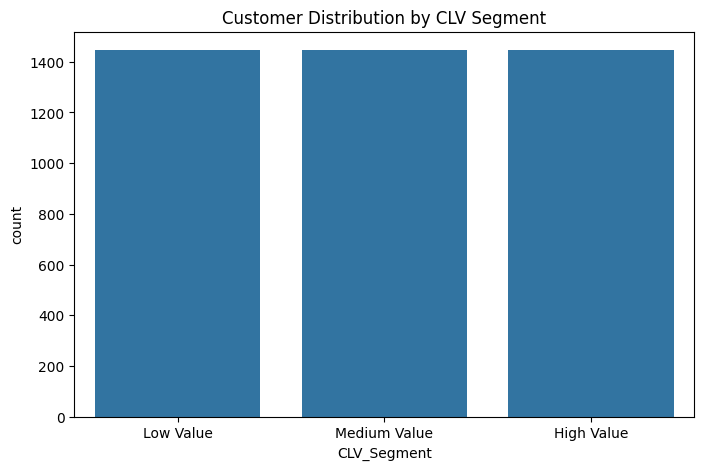

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="CLV_Segment",
    data=clv_df
)

plt.title("Customer Distribution by CLV Segment")
plt.show()

Revenue Contribution ---

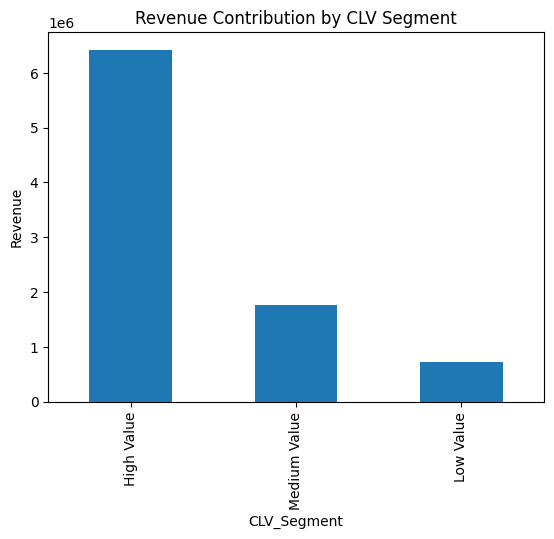

In [14]:
clv_revenue.plot(
    kind="bar"
)

plt.title("Revenue Contribution by CLV Segment")
plt.ylabel("Revenue")
plt.show()

Saving the output ---

In [15]:
clv_df.to_csv("C:/Data Analytics/Projects/Project3 E-commerce Customer Behavior & Revenue Analytics/clv_analysis.csv")

In [16]:
clv_df["CLV"].describe()

count      4338.000000
mean       1790.684573
std        7674.836604
min          14.738451
25%         763.088635
50%        1255.545136
75%        1837.452286
max      359858.502766
Name: CLV, dtype: float64

In [17]:
clv_df["CLV_Segment"].value_counts()

CLV_Segment
Low Value       1446
Medium Value    1446
High Value      1446
Name: count, dtype: int64

In [18]:
clv_revenue

CLV_Segment
High Value      6421728.692
Medium Value    1759987.900
Low Value        729691.312
Name: Revenue, dtype: float64